## CSCI-4041 - Algorithms - Chapter 11 - Hash Maps

### Joy Upton Azzam

### 3/15/2026

<mark>_____________________________________________________________________________________</mark>

## Probe Hash Map

The following python class ```probehashmap``` is my implementation based on the brief description below from page 294 in chapter 11 of the CLRS textbook.

<div style="width:33%; margin: auto;">
    
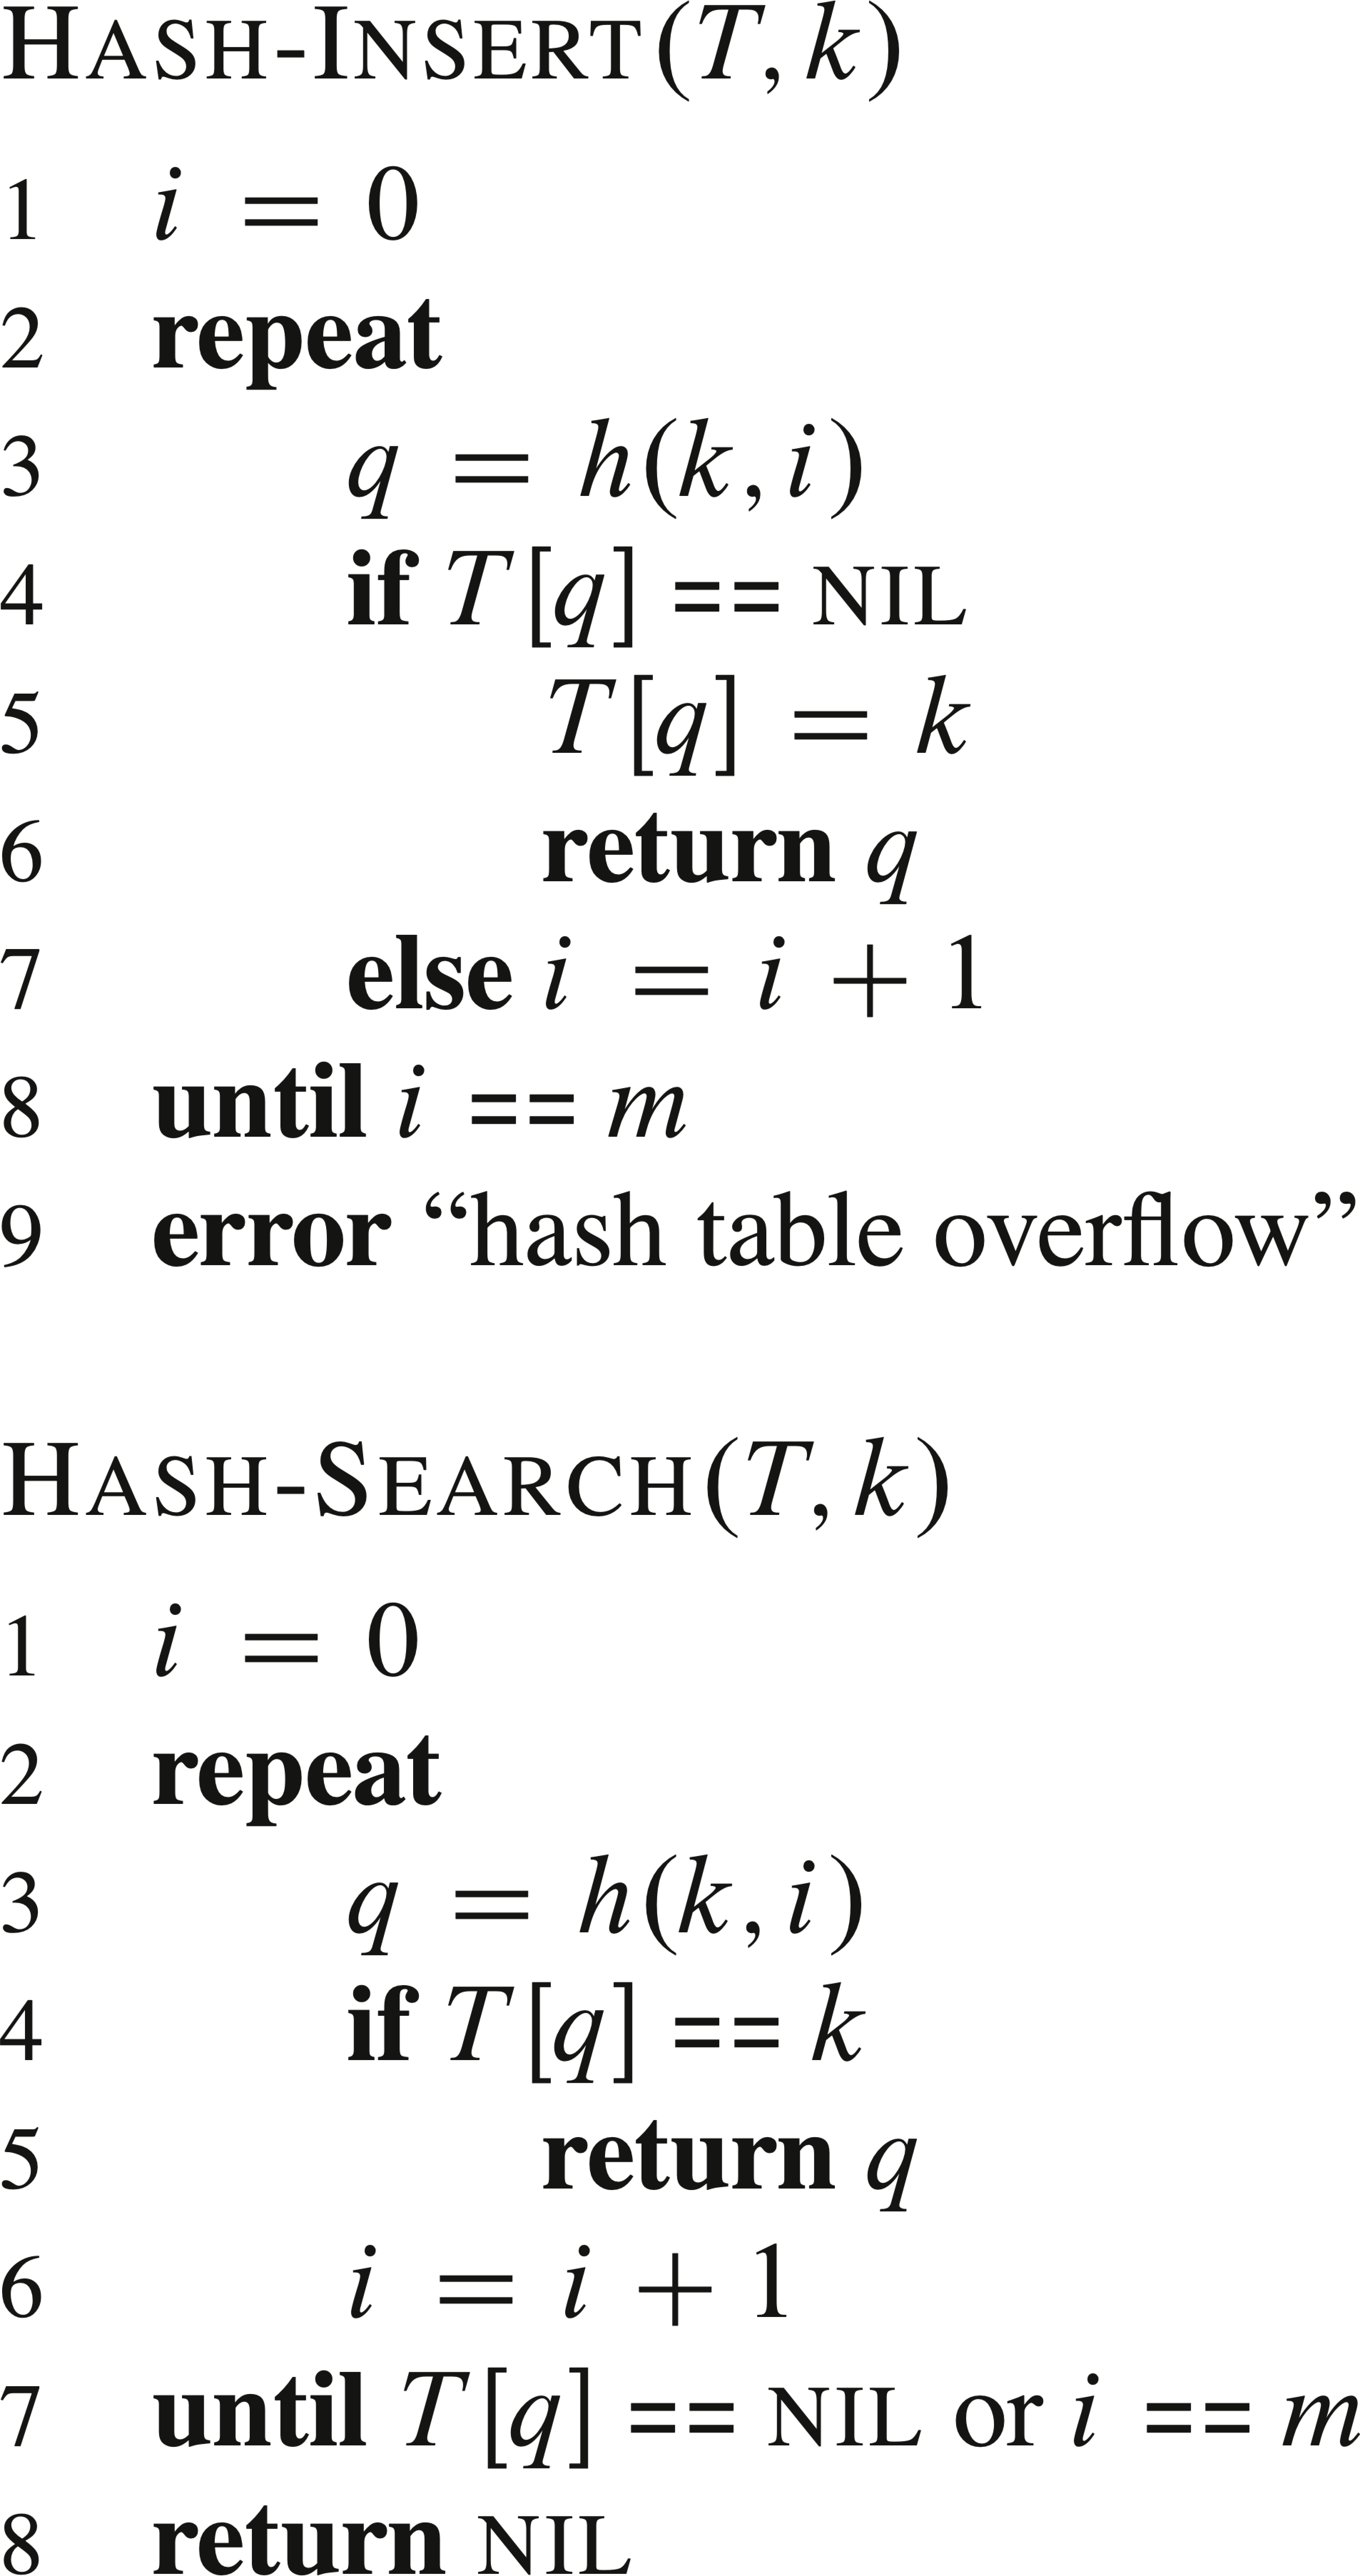

</div>

<mark>_____________________________________________________________________________________</mark>

### 1. Probe Hash Map

In [ ]:
class probehashmap:
    """a hash map which implements linear probing for collision resolution"""
    
    def __init__(self,capacity=11):
        """constructor for hash maps"""
        self.m = capacity # table size
        self.table = [None for i in range(capacity)]
    
    def h(self,key):
        """hash function for map -using python hash and division method"""
        return hash(key)%self.m
    
    def insert(self,k):
        """insert key k into the table"""
        hash_idx = self.h(k)     # compute the hash of key k
        
        i = 0
        while i < self.m:
            q = (hash_idx + i) % self.m  # linear probing
            if self.table[q] in [None,"__DELETED__"]:
                self.table[q] = k        # store key
                return q                 # return the storage index
            else:
                i = i + 1                # move forward
        if i==self.m:
            raise Exception("hash table overflow")
    
    def search(self,k):
        """search the table for key"""
        hash_idx = self.h(k)     # compute the hash of key k
        
        i = 0
        while i < self.m:
            q = (hash_idx + i) % self.m  # linear probing
            if self.table[q] == k:
                return q               # return the storage index
            elif self.table[q] == None:
                return None            # check for end of probe sequence
            else:
                i = i + 1              # move forward
        if i==self.m:
            return None
        
    def delete(self,q):
        """delete the key in index q (based on comments on page 294 of CLRS textbook)"""
        self.table[q] = "__DELETED__"
    
    def __str__(self):
        """printing utility for chain hash map"""
        return str(self.table)

<mark>_____________________________________________________________________________________</mark>

### 3. Testing

#### (a) contstructor usage

In [5]:
M = probehashmap()

#### (b) insert and __str__ (print) usage

In [7]:
M.insert("Apple")
print(M)

[None, 'Apple', None, None, None, None, None, None, None, None, None]


In [8]:
M.insert("Banana")
print(M)

[None, 'Apple', None, None, None, None, None, None, None, None, 'Banana']


In [10]:
M.insert("Orange")
print(M)

[None, 'Apple', 'Orange', None, None, None, None, None, None, None, 'Banana']


In [11]:
M.insert("Pear")
print(M)

['Pear', 'Apple', 'Orange', None, None, None, None, None, None, None, 'Banana']


In [12]:
M.insert("Grapes")
print(M)

['Pear', 'Apple', 'Orange', None, None, None, 'Grapes', None, None, None, 'Banana']


#### (c) search usage

In [20]:
idx = M.search("Pear")
print(idx)
print(M.table[idx])

0
Pear


In [22]:
x2 = M.search("Pineapple")
print(x2)

None


#### (d) delete usage

In [25]:
print(M)
print("deleting index =",idx,"from the table")
M.delete(idx)
print(M)

['Pear', 'Apple', 'Orange', None, None, None, 'Grapes', None, None, None, 'Banana']
deleting index = 0 from the table
['__DELETED__', 'Apple', 'Orange', None, None, None, 'Grapes', None, None, None, 'Banana']


In [27]:
x3 = M.search("Banana")
print(x3)

10


In [29]:
print(M)
print("deleting key =",x3,"from the table")
M.delete(x3)
print(M)

['__DELETED__', 'Apple', 'Orange', None, None, None, 'Grapes', None, None, None, 'Banana']
deleting key = 10 from the table
['__DELETED__', 'Apple', 'Orange', None, None, None, 'Grapes', None, None, None, '__DELETED__']


<mark>_____________________________________________________________________________________</mark>

### 4. Additional Testing Tools

In [33]:
import random

def rand_key(n=3):
    """returns a random string of length 3"""
    out = ""
    for i in range(n):
        out += chr(random.randint(ord('A'),ord('Z')))
    return out

In [35]:
for i in range(10):
    print(rand_key())

NTU
NCX
FJB
VXL
IBR
VQV
OMC
JPA
MEC
GII


<mark>_____________________________________________________________________________________</mark>

### 5. Randomized Chain Hash Map Tests

In [39]:
N = 10
M = probehashmap(N)

KEYS = []
for i in range(N):
    k = rand_key()
    while k in KEYS:
        k = rand_key()
    KEYS.append(k)
    M.insert(k)
print(M)
#print("\nkeys = ",KEYS)

['UBV', 'PVF', 'NAH', 'FZO', 'JMH', 'IQP', 'XEA', 'GGJ', 'HFF', 'GZJ']


In [41]:
random.shuffle(KEYS)

for i in range(N//2):
    key = KEYS.pop()
    x = M.search(key) # extract item
    M.delete(x)       # delete item
print(M)          # print modified table

['__DELETED__', 'PVF', '__DELETED__', '__DELETED__', '__DELETED__', 'IQP', 'XEA', 'GGJ', '__DELETED__', 'GZJ']


In [43]:
for i in range(N//2):
    
    k = rand_key()
    while k in KEYS:
        k = rand_key()
    KEYS.append(k)
    print("inserting key",k)
    M.insert(k)
print(M)

inserting key PYF
inserting key RBK
inserting key KEW
inserting key DJA
inserting key KCN
['KCN', 'PVF', 'PYF', 'KEW', 'RBK', 'IQP', 'XEA', 'GGJ', 'DJA', 'GZJ']
